<a href="https://colab.research.google.com/github/icorvalanh/iele756-region-la-florida/blob/main/Tarea0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea 0: Setup & First Contact with All Three Datasets**


*   Integrantes : Ignacio Corvalán y Valentina Cornejo
*   Profesor: Leo Ferres
*   Ayudante: Antuan Vayisqui
*   Comuna Asignada: La Florida




In [30]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


aca verificamos que pandas este instalado y corriendo correctamente

# Parte 1: CENSUS 2024
En esta sección se carga la base de personas del Censo 2024 y se filtra la información correspondiente a la comuna de La Florida, ubicada en la Región Metropolitana. Luego, se revisa la estructura básica de los datos y se analiza la distribución de nacionalidad.

In [31]:
import pandas as pd

# Asegúrate de que el archivo esté cargado en la carpeta actual
path = "personas_censo2024.parquet"

persona = pd.read_parquet(
    path,
    columns=[
        "region", "comuna", "sexo", "edad",
        "p27_nacionalidad", "p27_nacionalidad_rec",
        "escolaridad", "sit_fuerza_trabajo"
    ]
)

# Visualizamos las primeras filas para confirmar que cargó bien
persona.head()

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0


In [32]:
print("persona.shape")
print(persona.shape)

print("\npersona.dtypes")
print(persona.dtypes)

print("\npersona.head(10)")
display(persona.head(10))

print("\npersona.info()")
persona.info()


persona.shape
(18480432, 8)

persona.dtypes
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

persona.head(10)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN



persona.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


In [33]:
my_region = persona[persona["region"] == 13]
print(f"Rows in my region: {len(my_region):,}")


Rows in my region: 7,400,741


In [34]:
print(my_region["p27_nacionalidad_rec"].value_counts(dropna=False))


p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64


In [35]:
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True, dropna=False)
print(f"% foreign-born: {foreign.get(2, 0):.1%}")


% foreign-born: 12.2%


In [36]:
la_florida = persona[
    (persona["region"] == 13) & (persona["comuna"] == 13110)
]

print(f"Rows in La Florida: {len(la_florida):,}")
print(la_florida["p27_nacionalidad_rec"].value_counts(dropna=False))

foreign_lf = la_florida["p27_nacionalidad_rec"].value_counts(normalize=True, dropna=False)
print(f"% foreign-born in La Florida: {foreign_lf.get(2, 0):.1%}")


Rows in La Florida: 374,836
p27_nacionalidad_rec
 1     338618
 2      33978
-99      2240
Name: count, dtype: int64
% foreign-born in La Florida: 9.1%


## Parte 2: ENO

En esta sección se trabaja con la base ENO, correspondiente a enfermedades de notificación obligatoria. Primero se carga la base completa y luego se filtra a la Región Metropolitana, ya que la comuna asignada, La Florida, pertenece a esta región. Finalmente, se realiza una revisión descriptiva de las notificaciones por año, de las enfermedades más frecuentes y de la variable nacionalidad.


In [37]:
import pandas as pd

eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)


In [38]:
eno.head()


,etapa_clinica,region,seremi,nacionalidad,cie_10_diagnostico,diagnostico,Autóctono,anho_notificacion,ENO,pueblo_indigena,...,genotipo_1,recuento_linfocitos,clasificacion_final_vih,etapa_vih_sida,hospitalizacion,nombre_primer_sintoma,SeroGrupo,sexo,grupo_edad,codigo_comuna_residencia
0,CONFIRMADA,Región de Tarapacá,TARAPACÁ,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,25-29,01107
1,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Desconocido,A90.X,FIEBRE DEL DENGUE,No,2018,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,70-74,05301
2,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,70-74,05109
3,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,40-44,05301
4,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2021,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,60-64,05109


* Primero se carga la base ENO en formato CSV. Esta base utiliza separador punto y coma, por lo que se especifica `sep=";"` para su correcta lectura.
* luego se revisa si se subió correctamente la base

In [39]:
print("eno.shape")
print(eno.shape)

print("\neno.columns")
print(eno.columns.tolist())

print("\neno.head(10)")
display(eno.head(10))


eno.shape
(333300, 39)

eno.columns
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']

eno.head(10)


,etapa_clinica,region,seremi,nacionalidad,cie_10_diagnostico,diagnostico,Autóctono,anho_notificacion,ENO,pueblo_indigena,...,genotipo_1,recuento_linfocitos,clasificacion_final_vih,etapa_vih_sida,hospitalizacion,nombre_primer_sintoma,SeroGrupo,sexo,grupo_edad,codigo_comuna_residencia
0,CONFIRMADA,Región de Tarapacá,TARAPACÁ,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,25-29,01107
1,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Desconocido,A90.X,FIEBRE DEL DENGUE,No,2018,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,70-74,05301
2,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,70-74,05109
3,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,40-44,05301
4,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2021,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,60-64,05109
5,CONFIRMADA,Región Metropolitana de Santiago,RM,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,45-49,13114
6,CONFIRMADA,Región Metropolitana de Santiago,RM,Chile,A97.9,"DENGUE, NO ESPECIFICADO",No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,45-49,13104
7,CONFIRMADA,Región Metropolitana de Santiago,RM,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,55-59,13129
8,CONFIRMADA,Región Metropolitana de Santiago,RM,Chile,A97.9,"DENGUE, NO ESPECIFICADO",No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,50-54,13129
9,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,50-54,05107


A continuación, se inspecciona la base completa para conocer su tamaño, sus columnas disponibles y la estructura general de los registros.


In [40]:
eno["region"].value_counts(dropna=False)


,count
region,
Región Metropolitana de Santiago,126669
Región del Biobío,38592
Región de Valparaíso,36373
Región de Coquimbo,21373
Región de Antofagasta,18302
Región de Los Lagos,17829
Región de Tarapacá,13778
Región de la Araucanía,11593
Región del Libertador General Bernardo OHiggins,10765


In [41]:
eno_rm = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Filas en la Región Metropolitana: {len(eno_rm):,}")


Filas en la Región Metropolitana: 126,669


Luego se filtran los registros correspondientes a la Región Metropolitana, que es la región a la que pertenece la comuna de La Florida. Este filtro permitirá realizar un análisis  centrado en la comuna asignada.


In [42]:
notif_year = eno_rm["anho_notificacion"].value_counts().sort_index()
print(notif_year)


anho_notificacion
2007     3930
2008     3830
2009     4015
2010     4693
2011     6151
2012     5857
2013     6006
2014     6005
2015     6129
2016     6023
2017    10865
2018    13256
2019    10287
2020     7182
2021     7457
2022    10496
2023     9395
2024     5092
Name: count, dtype: int64


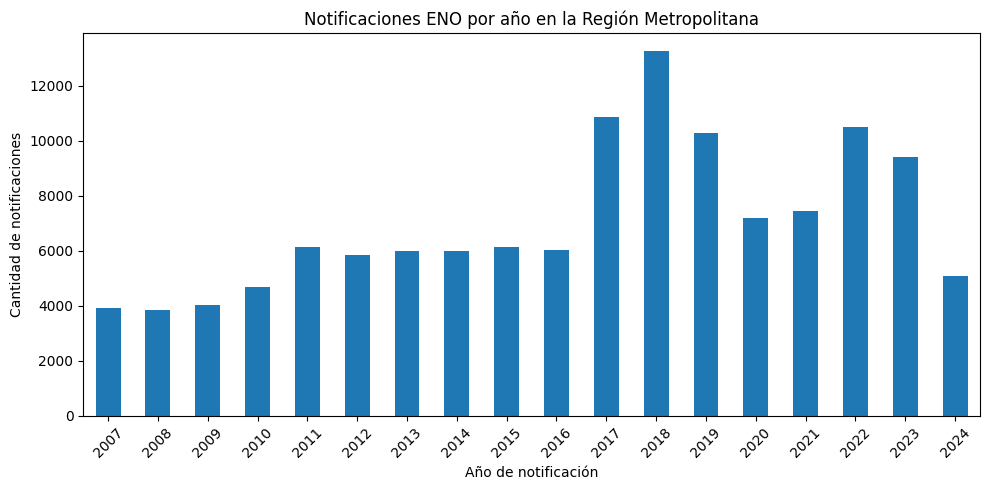

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
notif_year.plot(kind="bar")
plt.title("Notificaciones ENO por año en la Región Metropolitana")
plt.xlabel("Año de notificación")
plt.ylabel("Cantidad de notificaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Se calcula la cantidad de notificaciones por año utilizando la variable `anho_notificacion`. Luego, se representa esta información mediante un gráfico de barras para visualizar la evolución temporal de los registros en la región.


In [44]:
top5_diseases = eno_rm["ENO"].value_counts().head(5)
print(top5_diseases)


ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64


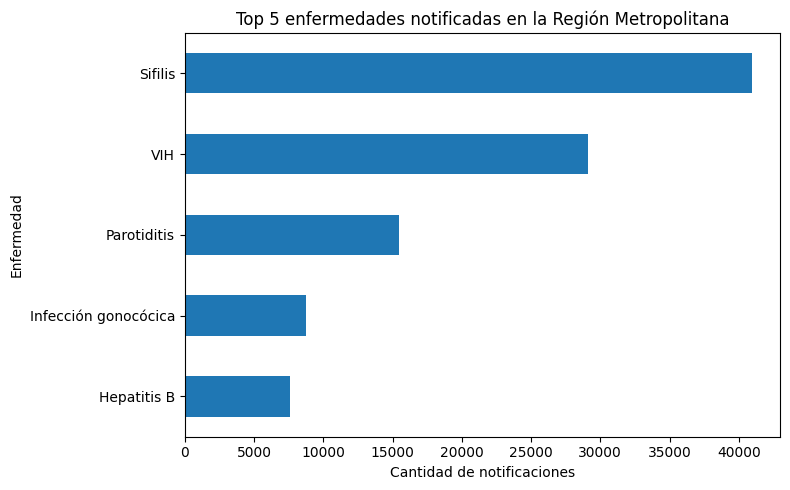

In [45]:
plt.figure(figsize=(8,5))
top5_diseases.sort_values().plot(kind="barh")
plt.title("Top 5 enfermedades notificadas en la Región Metropolitana")
plt.xlabel("Cantidad de notificaciones")
plt.ylabel("Enfermedad")
plt.tight_layout()
plt.show()


Posteriormente, se identifican las cinco enfermedades con mayor frecuencia de notificación en la Región Metropolitana. Esta revisión permite obtener una primera aproximación a los eventos más recurrentes dentro de la base ENO.


In [46]:
eno_rm["nacionalidad"].value_counts(dropna=False)


,count
nacionalidad,
Desconocido,55863
Chile,47093
Extranjero,23713


Finalmente, se revisa la distribución de la variable `nacionalidad` dentro de la base ENO filtrada. En esta etapa se mantienen todas las categorías presentes en los datos, incluyendo posibles valores como “Desconocido”, para no omitir información relevante.


## Conclusión Parte 2

Se logró cargar y filtrar correctamente la base ENO para la Región Metropolitana. A partir de ello, fue posible identificar la distribución de notificaciones por año, las enfermedades más frecuentes y la composición de la variable nacionalidad en los registros analizados.

## Parte 3: GRD

En esta sección se trabaja con la base GRD, correspondiente a egresos hospitalarios. Primero se carga la base y se seleccionan únicamente las columnas necesarias para el análisis. Luego, se filtran los registros correspondientes a la comuna de La Florida. Finalmente, se incorpora la tabla CIE-10 para obtener la descripción de los diagnósticos y se identifican los cinco diagnósticos más frecuentes.


In [47]:
import pandas as pd

cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
    "FECHA_INGRESO", "FECHAALTA",
    "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"
]

grd = pd.read_csv(
    "GRD_PUBLICO_2024.txt",
    sep="|",
    usecols=cols,
    encoding="latin-1",
    low_memory=False
)


In [48]:
grd.head()


,SEXO,COMUNA,NACIONALIDAD,FECHA_INGRESO,FECHAALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_SEVERIDAD
0,MUJER,VILLA ALEMANA,CHILE,2024-03-23,2024-03-23,H26.9,022360,0
1,MUJER,VIÑA DEL MAR,CHILE,2024-09-26,2024-10-02,M31.1,041023,3
2,HOMBRE,LA SERENA,CHILE,2024-01-22,2024-01-26,K12.2,034141,1
3,HOMBRE,ÑUÑOA,CHILE,2024-04-08,2024-04-14,C61,061203,3
4,MUJER,SAN PEDRO DE LA PAZ,PERÚ,2024-09-24,2024-09-26,K35.8,061131,1


Primero se carga la base GRD del año 2024. Debido al gran número de columnas disponibles, se seleccionan únicamente aquellas necesarias para esta primera exploración de los datos.


In [49]:
print("grd.shape")
print(grd.shape)

print("\ngrd.dtypes")
print(grd.dtypes)

print("\ngrd.head(10)")
display(grd.head(10))


grd.shape
(1085813, 8)

grd.dtypes
SEXO                  object
COMUNA                object
NACIONALIDAD          object
FECHA_INGRESO         object
FECHAALTA             object
DIAGNOSTICO1          object
IR_29301_COD_GRD      object
IR_29301_SEVERIDAD    object
dtype: object

grd.head(10)


,SEXO,COMUNA,NACIONALIDAD,FECHA_INGRESO,FECHAALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_SEVERIDAD
0,MUJER,VILLA ALEMANA,CHILE,2024-03-23,2024-03-23,H26.9,022360,0
1,MUJER,VIÑA DEL MAR,CHILE,2024-09-26,2024-10-02,M31.1,041023,3
2,HOMBRE,LA SERENA,CHILE,2024-01-22,2024-01-26,K12.2,034141,1
3,HOMBRE,ÑUÑOA,CHILE,2024-04-08,2024-04-14,C61,061203,3
4,MUJER,SAN PEDRO DE LA PAZ,PERÚ,2024-09-24,2024-09-26,K35.8,061131,1
5,MUJER,TOME,CHILE,2024-01-05,2024-01-05,Z30.2,132210,0
6,MUJER,CONCEPCIÓN,CHILE,2024-12-05,2024-12-16,K80.5,074143,3
7,HOMBRE,SAN FELIPE,CHILE,2024-08-31,2024-08-31,K40.9,062140,0
8,MUJER,PUNTA ARENAS,CHILE,2024-01-03,2024-01-05,D06.9,131301,1
9,MUJER,PUNTA ARENAS,CHILE,2023-12-31,2024-01-03,O47.0,134151,1


A continuación, se inspecciona la estructura general de la base GRD para conocer su tamaño, los tipos de datos y la forma en que se presentan los registros seleccionados.


In [50]:
grd["COMUNA"].value_counts(dropna=False).head(50)


,count
COMUNA,
PUENTE ALTO,39492
LA FLORIDA,21818
MAIPU,21493
VALPARAISO,20756
ARICA,20352
ANTOFAGASTA,19499
LOS ÁNGELES,18947
PUERTO MONTT,18859
SANTIAGO,18799


In [51]:
grd_lf = grd[grd["COMUNA"] == "LA FLORIDA"]
print(f"Filas en La Florida: {len(grd_lf):,}")


Filas en La Florida: 21,818


Luego se filtran los registros correspondientes a la comuna de La Florida, que es el territorio asignado para esta tarea. En la base GRD, este filtro se realiza utilizando directamente la variable `COMUNA`.


In [52]:
cie10 = pd.read_excel(
    "CIE-10.xlsx",
    sheet_name="CIE 10"
)

cie10.head()


,Versión,Código,Descripción,Categoría,Sección,Capítulo
0,CIE-v2013,A00,Cólera,A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
1,CIE-v2013,A00.0,"Cólera debido a Vibrio cholerae O1, biotipo ch...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
2,CIE-v2013,A00.1,"Cólera debido a Vibrio cholerae O1, biotipo El...",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
3,CIE-v2013,A00.9,"Cólera, no especificado",A00 CÓLERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
4,CIE-v2013,A01,Fiebres tifoidea y paratifoidea,A01 FIEBRES TIFOIDEA Y PARATIFOIDEA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...


In [53]:
cie10.columns.tolist()


['Versión', 'Código', 'Descripción', 'Categoría', 'Sección', 'Capítulo']

Posteriormente, se incorpora la tabla CIE-10


In [54]:
grd_lf_merged = pd.merge(grd_lf, cie10, left_on="DIAGNOSTICO1", right_on="Código", how="left")
top5_diag = grd_lf_merged["Descripción"].value_counts().head(5)
print(top5_diag)

Descripción
Catarata senil, no especificada                   647
Cálculo de la vesícula biliar sin colecistitis    465
Sesión de quimioterapia por tumor                 346
Infarto subendocárdico agudo del miocardio        334
Otras atenciones médicas especificadas            271
Name: count, dtype: int64


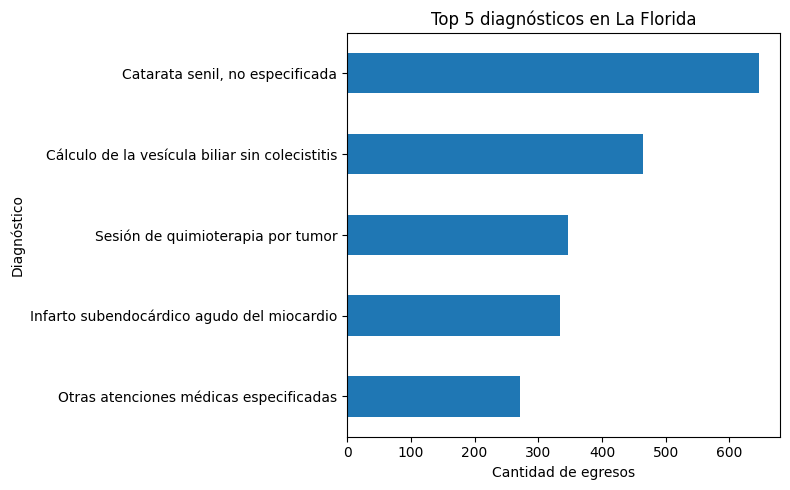

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
top5_diag.sort_values().plot(kind="barh")
plt.title("Top 5 diagnósticos en La Florida")
plt.xlabel("Cantidad de egresos")
plt.ylabel("Diagnóstico")
plt.tight_layout()
plt.show()


### Conclusiones del Análisis: Top 5 Diagnósticos en La Florida

A partir de la visualización de los datos procesados, se presentan las siguientes conclusiones clave:

1. **Prevalencia de Cataratas:** El diagnóstico de **"Catarata senil, no especificada"** lidera la lista con cerca de 70 egresos, siendo la causa de hospitalización más frecuente en la comuna durante este periodo.
2. **Carga de Enfermedades Crónicas:** La presencia significativa de **"Sesión de quimioterapia por tumor"** e **"Infarto subendocárdico agudo del miocardio"** refleja una alta demanda de recursos para tratamientos oncológicos y cardiovasculares de alta complejidad.
3. **Perfil de Morbilidad:** Los datos muestran una predominancia de patologías asociadas al envejecimiento y enfermedades no transmisibles, lo que sugiere que la infraestructura hospitalaria en La Florida está fuertemente orientada a la atención de adultos mayores y enfermedades crónicas.
4. **Estandarización CIE-10:** La correcta identificación de estos diagnósticos mediante la tabla **CIE-10** permite validar que los registros analizados son consistentes con los estándares internacionales de codificación clínica.